In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

try:
    engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}')
    query="""
            select
                o.order_purchase_timestamp::date as order_day,
                oi.product_id,
                p.product_category_name as category_name,
                sum(oi.price) as revenue 
            from
                analytics.fact_orders_items oi
            left join
                analytics.fact_orders o
                on o.order_id = oi.order_id
            left join        
		        analytics.dim_products p
                on p.product_id = oi.product_id
            where
                product_category_name is not null
            group by
                p.product_category_name, oi.product_id, o.order_purchase_timestamp
            order by
                o.order_purchase_timestamp asc;
        """
    analysis_df = pd.read_sql(query, con=engine)
 
except Exception as e:
    print(f"Detail error: {e}")
finally:
    engine.dispose()

## Exploratory analysis of the dataset

In [2]:
analysis_df

,order_day,product_id,category_name,revenue
0,2016-09-04,c1488892604e4ba5cff5b4eb4d595400,moveis_decoracao,79.98
1,2016-09-04,f293394c72c9b5fafd7023301fc21fc2,moveis_decoracao,65.80
2,2016-09-05,f3c2d01a84c947b078e32bbef0718962,telefonia,59.50
3,2016-09-15,5a6b04657a4c5ee34285d1e4619a96b4,beleza_saude,404.91
4,2016-10-02,d2998d7ced12f83f9b832f33cf6507b6,bebes,100.00
...,...,...,...,...
100928,2018-08-29,2b4472df15512a2825ae86fd9ae79335,moveis_cozinha_area_de_servico_jantar_e_jardim,836.00
100929,2018-08-29,bdcf6a834e8faa30dac3886c7a58e92e,beleza_saude,45.90
100930,2018-08-29,c7f27c5bef2338541c772b5776403e6a,artigos_de_festas,24.90
100931,2018-08-29,d04857e7b4b708ee8b8b9921163edba3,informatica_acessorios,84.99


In [3]:
analysis_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100933 entries, 0 to 100932
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   order_day      100933 non-null  object 
 1   product_id     100933 non-null  str    
 2   category_name  100933 non-null  str    
 3   revenue        100933 non-null  float64
dtypes: float64(1), object(1), str(2)
memory usage: 3.1+ MB


In [4]:
analysis_df.isnull().sum()

order_day        0
product_id       0
category_name    0
revenue          0
dtype: int64

In [5]:
analysis_df = analysis_df.drop("product_id", axis=1)

In [6]:
analysis_df

,order_day,category_name,revenue
0,2016-09-04,moveis_decoracao,79.98
1,2016-09-04,moveis_decoracao,65.80
2,2016-09-05,telefonia,59.50
3,2016-09-15,beleza_saude,404.91
4,2016-10-02,bebes,100.00
...,...,...,...
100928,2018-08-29,moveis_cozinha_area_de_servico_jantar_e_jardim,836.00
100929,2018-08-29,beleza_saude,45.90
100930,2018-08-29,artigos_de_festas,24.90
100931,2018-08-29,informatica_acessorios,84.99


In [7]:
analysis_df = (analysis_df.groupby(["order_day", "category_name"])["revenue"].sum().reset_index())

In [8]:
analysis_df["order_day"] = pd.to_datetime(analysis_df["order_day"])
analysis_df.set_index("order_day", inplace=True)

In [9]:
analysis_df

,category_name,revenue
order_day,,
2016-09-04,moveis_decoracao,145.78
2016-09-05,telefonia,59.50
2016-09-15,beleza_saude,404.91
2016-10-02,bebes,100.00
2016-10-03,brinquedos,128.90
...,...,...
2018-08-29,esporte_lazer,6.90
2018-08-29,informatica_acessorios,84.99
2018-08-29,moveis_cozinha_area_de_servico_jantar_e_jardim,836.00


In [10]:
analysis_df["revenue"].describe()

count     18504.000000
mean        919.513379
std        1706.708582
min           3.500000
25%         129.797500
50%         400.845000
75%        1099.077500
max      107520.000000
Name: revenue, dtype: float64

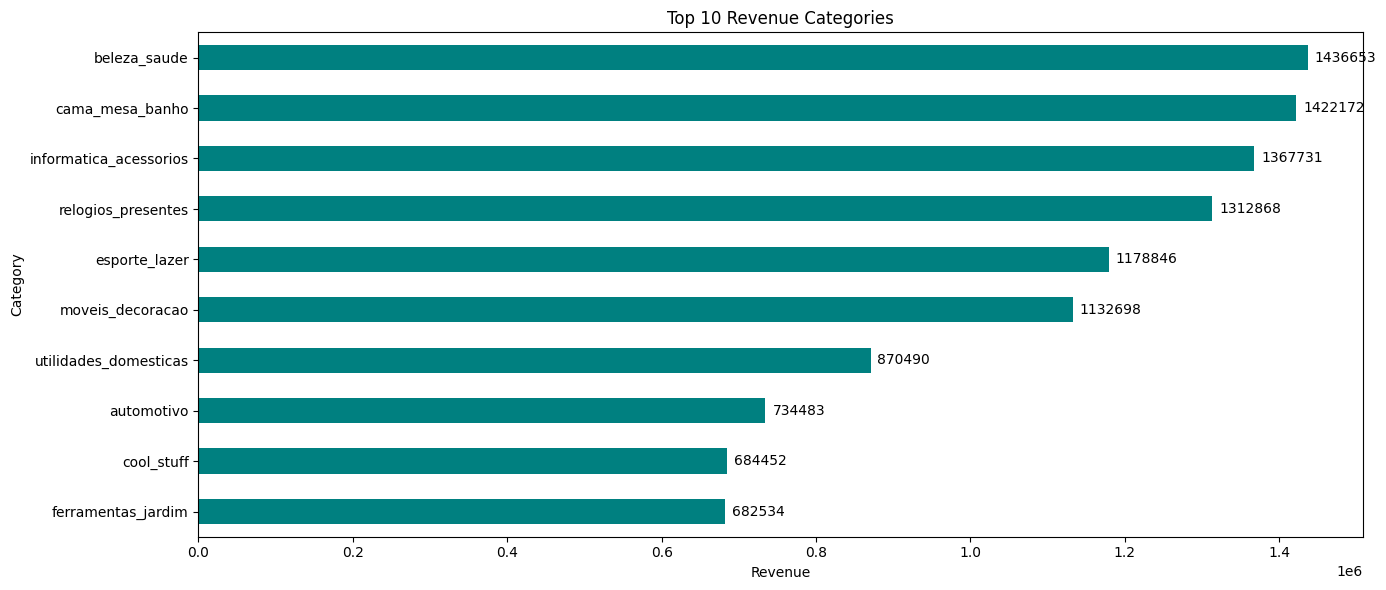

In [11]:
import matplotlib.pyplot as plt

top_10 = analysis_df.groupby('category_name')['revenue'].sum().sort_values(ascending=False).head(10)

ax = top_10.plot(kind='barh', color='teal', figsize=(14,6))
ax.invert_yaxis()

for container in ax.containers:
    ax.bar_label(container,
                fmt='%.0f',
                padding=5)
    
plt.title("Top 10 Revenue Categories")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()

plt.show()


## Feature Engineering

In [12]:
analysis_df["day_of_week"] = analysis_df.index.day_of_week
analysis_df["is_weekend"] = (analysis_df.index.day_of_week >=5).astype(int)
analysis_df["lag_7"] = analysis_df.groupby("category_name")["revenue"].shift(7)
analysis_df["lag_14"] = analysis_df.groupby("category_name")["revenue"].shift(14)

analysis_df["rolling_7"] = (analysis_df.groupby("category_name")["revenue"]
                            .transform(lambda x: x.rolling(7).mean())
                            )

analysis_df["rolling_14"] = (analysis_df.groupby("category_name")["revenue"]
                             .transform(lambda x: x.rolling(14).mean())
                             )

In [13]:
analysis_df

,category_name,revenue,day_of_week,is_weekend,lag_7,lag_14,rolling_7,rolling_14
order_day,,,,,,,,
2016-09-04,moveis_decoracao,145.78,6,1,NaN,NaN,NaN,NaN
2016-09-05,telefonia,59.50,0,0,NaN,NaN,NaN,NaN
2016-09-15,beleza_saude,404.91,3,0,NaN,NaN,NaN,NaN
2016-10-02,bebes,100.00,6,1,NaN,NaN,NaN,NaN
2016-10-03,brinquedos,128.90,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
2018-08-29,esporte_lazer,6.90,2,0,913.40,9137.19,549.472857,1144.552857
2018-08-29,informatica_acessorios,84.99,2,0,737.91,2163.67,350.234286,801.807143
2018-08-29,moveis_cozinha_area_de_servico_jantar_e_jardim,836.00,2,0,369.00,63.90,227.954286,227.083571


In [14]:
analysis_df.dropna(inplace=True)

In [15]:
analysis_df.isnull().sum()

category_name    0
revenue          0
day_of_week      0
is_weekend       0
lag_7            0
lag_14           0
rolling_7        0
rolling_14       0
dtype: int64

In [16]:
analysis_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 17512 entries, 2017-01-12 to 2018-09-03
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   category_name  17512 non-null  str    
 1   revenue        17512 non-null  float64
 2   day_of_week    17512 non-null  int32  
 3   is_weekend     17512 non-null  int64  
 4   lag_7          17512 non-null  float64
 5   lag_14         17512 non-null  float64
 6   rolling_7      17512 non-null  float64
 7   rolling_14     17512 non-null  float64
dtypes: float64(5), int32(1), int64(1), str(1)
memory usage: 1.1 MB


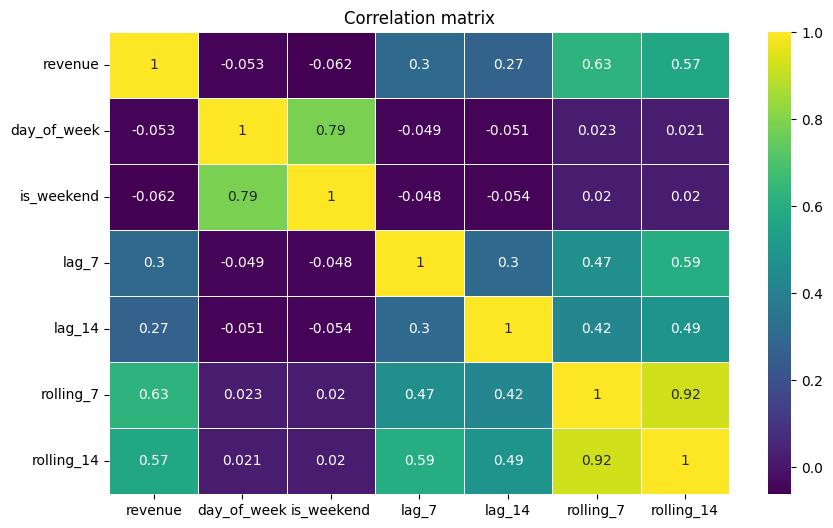

In [17]:
import seaborn as sns

numeric_df = analysis_df.select_dtypes(include="number")
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="viridis",
            linewidths=0.5)
plt.title("Correlation matrix")

plt.show()


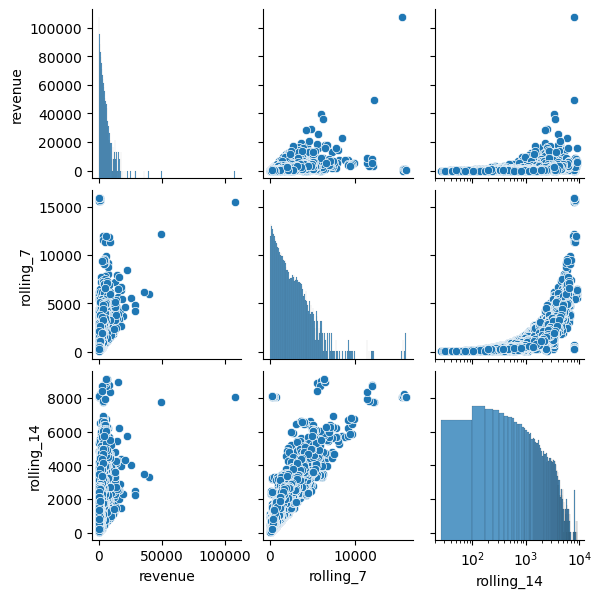

In [18]:
sns.pairplot(numeric_df[["revenue", "rolling_7", "rolling_14"]], height=2)
plt.xscale("log")
plt.yscale("log")

## Training and Test Dataset

In [19]:
base_df = analysis_df.copy()

ml_df = pd.get_dummies(
    base_df,
    columns=["category_name"],
    drop_first=True
)

In [20]:
x = ml_df.drop("revenue", axis=1)
y = ml_df["revenue"]

In [21]:
train_size = int(len(x)*0.80)

In [22]:
X_train = x.iloc[:train_size]
X_test = x.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

## Model Training

### Baseline

### Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Random Forest

In [25]:
from sklearn.ensemble import RandomForestRegressor

In [26]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### XGBoost

In [27]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42)

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

### ElasticNet

In [28]:
from sklearn.linear_model import ElasticNet

elastic_model = ElasticNet(
    alpha=1.0,
    l1_ratio=0.5,
    random_state=42
)

elastic_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### LightGBM

In [29]:
from lightgbm import LGBMRegressor

lgbm_model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    verbose=-1
)

lgbm_model.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


### Prediction phase

In [30]:
lr_predict = lr_model.predict(X_test)

rf_predict = rf_model.predict(X_test)

xgb_predict = xgb_model.predict(X_test)

elastic_predict = elastic_model.predict(X_test)

lgbm_predict = lgbm_model.predict(X_test)

### Metrics

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error)
import numpy as np

def evaluate_model(y_true, y_predict):
    mae = mean_absolute_error(y_true, y_predict)
    mse = mean_squared_error(y_true, y_predict)
    mape = mean_absolute_percentage_error(y_true, y_predict)

    return mae, mse, mape

In [32]:
mae_lr, mse_lr, mape_lr = evaluate_model(y_test, lr_predict)

mae_rf, mse_rf, mape_rf = evaluate_model(y_test, rf_predict)

mae_xgb, mse_xgb, mape_xgb = evaluate_model(y_test, xgb_predict)

mae_elastic, mse_elastic, mape_elastic = evaluate_model(y_test, elastic_predict)

mae_lgbm, mse_lgbm, mape_lgbm = evaluate_model(y_test, lgbm_predict)

In [33]:
result = pd.DataFrame({"MODELS": ["Linear Regression", "Random Forest", "XGBoost", "ElasticNet", "LightGBM"], 
                        "MAE": [mae_lr, mae_rf, mae_xgb, mae_elastic, mae_lgbm], 
                        "MSE": [mse_lr, mse_rf, mse_xgb, mse_elastic, mse_lgbm], 
                        "MAPE": [mape_lr, mape_rf, mape_xgb, mape_elastic, mape_lgbm] 
                        })
result = result.round(2)
result

,MODELS,MAE,MSE,MAPE
0,Linear Regression,558.35,1205098.74,2.18
1,Random Forest,586.46,2226368.15,2.14
2,XGBoost,580.18,3030239.66,2.00
3,ElasticNet,551.82,1202776.64,2.07
4,LightGBM,546.35,1231918.12,1.98


In [34]:
predict_df = base_df.iloc[train_size:].copy()
predict_df["predict_revenue"] = lgbm_predict

In [38]:
prediction_by_categories = predict_df[["category_name", "revenue", "predict_revenue"]]

In [40]:
prediction_by_categories

,category_name,revenue,predict_revenue
order_day,,,
2018-05-22,moveis_decoracao,3110.69,3339.378377
2018-05-22,moveis_escritorio,3016.19,961.615838
2018-05-22,papelaria,373.10,539.653675
2018-05-22,pcs,730.00,3042.365029
2018-05-22,perfumaria,518.51,1405.489232
...,...,...,...
2018-08-29,esporte_lazer,6.90,733.900949
2018-08-29,informatica_acessorios,84.99,440.018591
2018-08-29,moveis_cozinha_area_de_servico_jantar_e_jardim,836.00,258.231993
